This notebook implements the naive Mono-Forward Algorithm with the gradients

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")
result_paths = sorted(RESULTS_DIR.glob("*.json"))

result_paths

[WindowsPath('results/mlp_cifar100_20260428_203827.json'),
 WindowsPath('results/mlp_cifar10_20260428_194837.json'),
 WindowsPath('results/mlp_fashionmnist_20260428_185912.json'),
 WindowsPath('results/mlp_mnist_20260428_183125.json')]

## Training and test losses

In [3]:
def load_experiment_history(path: Path) -> pd.DataFrame:
    raw = pd.read_json(path)
    name_parts = path.stem.split("_")
    model = name_parts[0]
    dataset = name_parts[1]
    run_id = "_".join(name_parts[2:])

    rows = []
    for method in raw.columns:
        for metric, values in raw[method].items():
            for epoch, value in enumerate(values, start=1):
                rows.append(
                    {
                        "file": path.name,
                        "model": model,
                        "dataset": dataset,
                        "run_id": run_id,
                        "method": method,
                        "metric": metric,
                        "epoch": epoch,
                        "value": value,
                    }
                )

    return pd.DataFrame(rows)


history = pd.concat(
    [load_experiment_history(path) for path in result_paths],
    ignore_index=True,
)

losses = (
    history[history["metric"].isin(["train_losses", "test_losses"])]
    .copy()
    .assign(
        split=lambda df: df["metric"].str.replace("_losses", "", regex=False),
        method_label=lambda df: df["method"].map(
            {
                "mono_ff": "MonoFWD FF",
                "mono_bp": "MonoFWD BP",
                "bp": "Backprop",
            }
        ),
    )
)

accuracies = (
    history[history["metric"].isin(["train_accs", "test_accs"])]
    .copy()
    .assign(
        split=lambda df: df["metric"].str.replace("_accs", "", regex=False),
        method_label=lambda df: df["method"].map(
            {
                "mono_ff": "MonoFWD FF",
                "mono_bp": "MonoFWD BP",
                "bp": "Backprop",
            }
        ),
    )
)

display(losses.head())
display(
    losses.groupby(["dataset", "method_label", "split"])["epoch"]
    .max()
    .rename("epochs")
    .to_frame()
)

,file,model,dataset,run_id,method,metric,epoch,value,split,method_label
0,mlp_cifar100_20260428_203827.json,mlp,cifar100,20260428_203827,mono_ff,train_losses,1,5.364591,train,MonoFWD FF
1,mlp_cifar100_20260428_203827.json,mlp,cifar100,20260428_203827,mono_ff,train_losses,2,4.938159,train,MonoFWD FF
2,mlp_cifar100_20260428_203827.json,mlp,cifar100,20260428_203827,mono_ff,train_losses,3,4.639611,train,MonoFWD FF
3,mlp_cifar100_20260428_203827.json,mlp,cifar100,20260428_203827,mono_ff,train_losses,4,4.368280,train,MonoFWD FF
4,mlp_cifar100_20260428_203827.json,mlp,cifar100,20260428_203827,mono_ff,train_losses,5,4.064774,train,MonoFWD FF


epochs
dataset      method_label split        
cifar10      Backprop     test      100
                          train     100
             MonoFWD BP   test      100
                          train     100
             MonoFWD FF   test      100
                          train     100
cifar100     Backprop     test      100
                          train     100
             MonoFWD BP   test      100
                          train     100
             MonoFWD FF   test      100
                          train     100
fashionmnist Backprop     test      100
                          train     100
             MonoFWD BP   test      100
                          train     100
             MonoFWD FF   test      100
                          train     100
mnist        Backprop     test      100
                          train     100
             MonoFWD BP   test      100
                          train     100
             MonoFWD FF   test      100
                          train     100

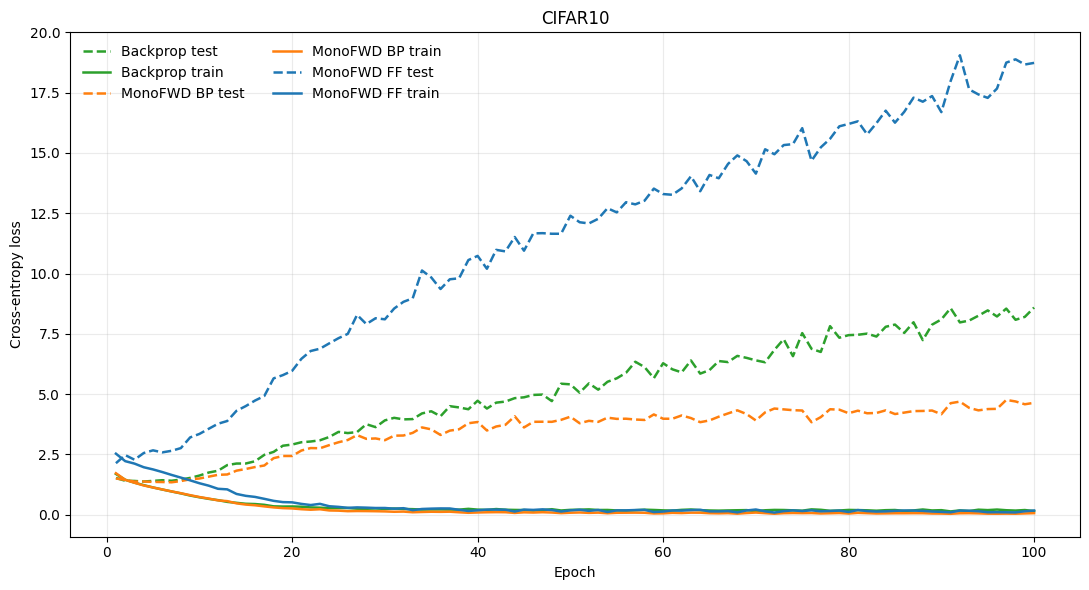

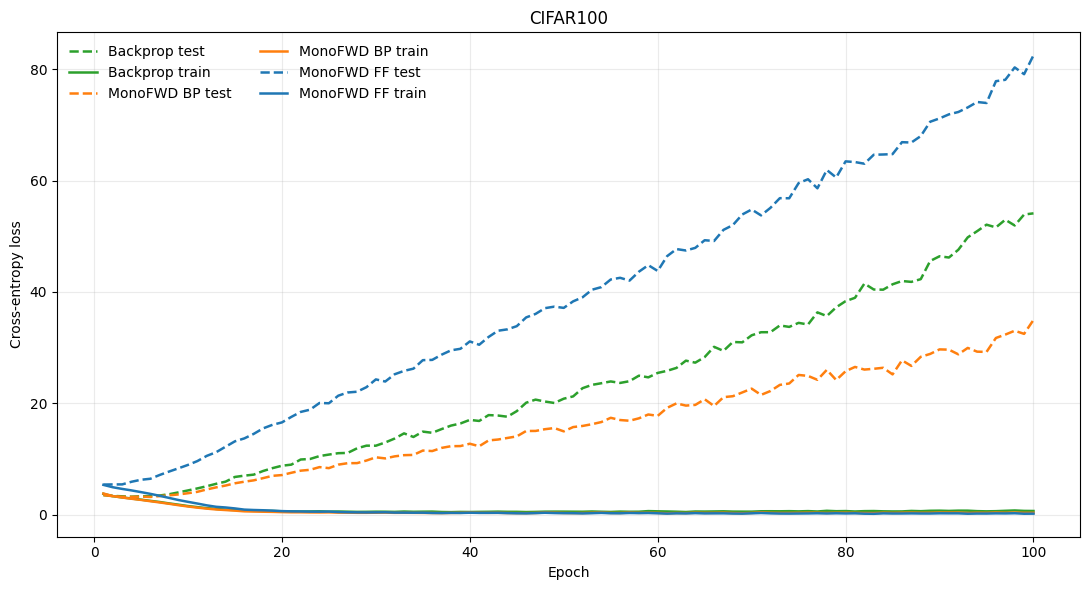

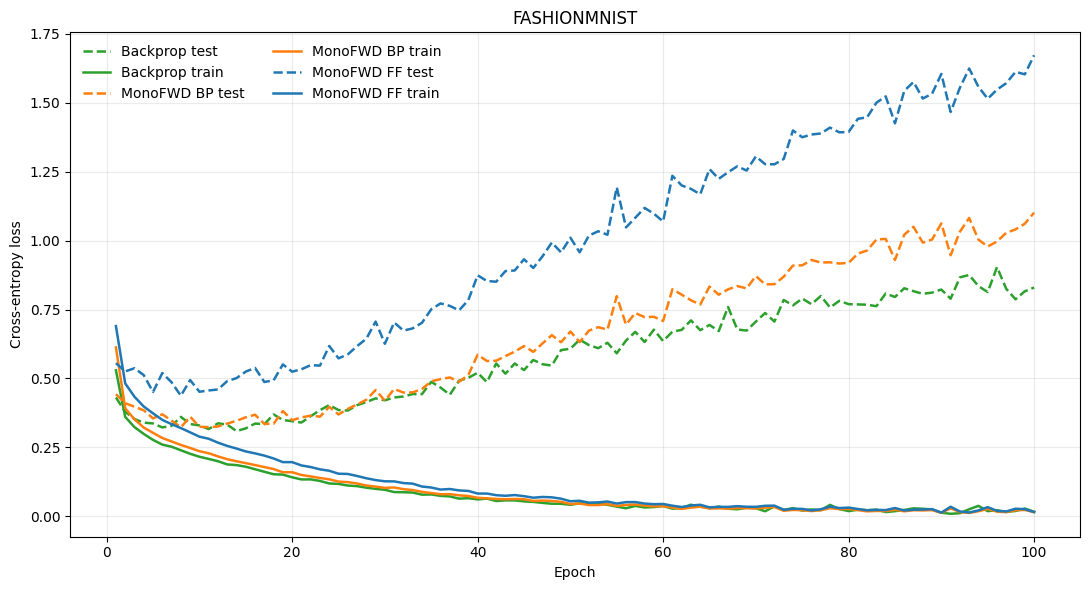

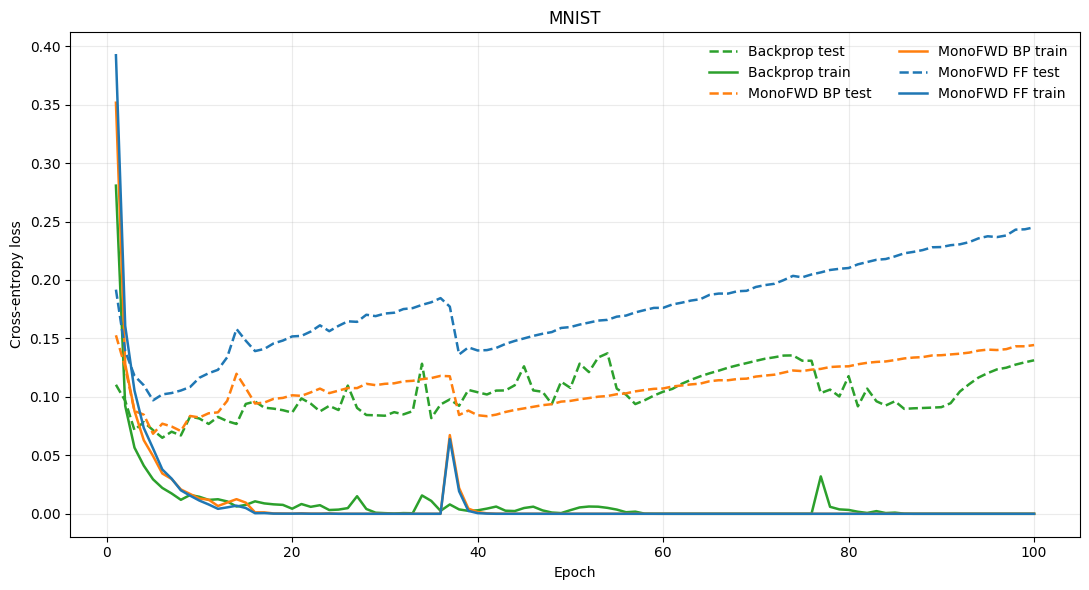

In [4]:
method_colors = {
    "MonoFWD FF": "tab:blue",
    "MonoFWD BP": "tab:orange",
    "Backprop": "tab:green",
}
split_styles = {"train": "-", "test": "--"}

for dataset in sorted(losses["dataset"].unique()):
    fig, ax = plt.subplots(figsize=(11, 6))
    dataset_losses = losses[losses["dataset"] == dataset]

    for (method_label, split), group in dataset_losses.groupby(["method_label", "split"]):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(dataset.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()

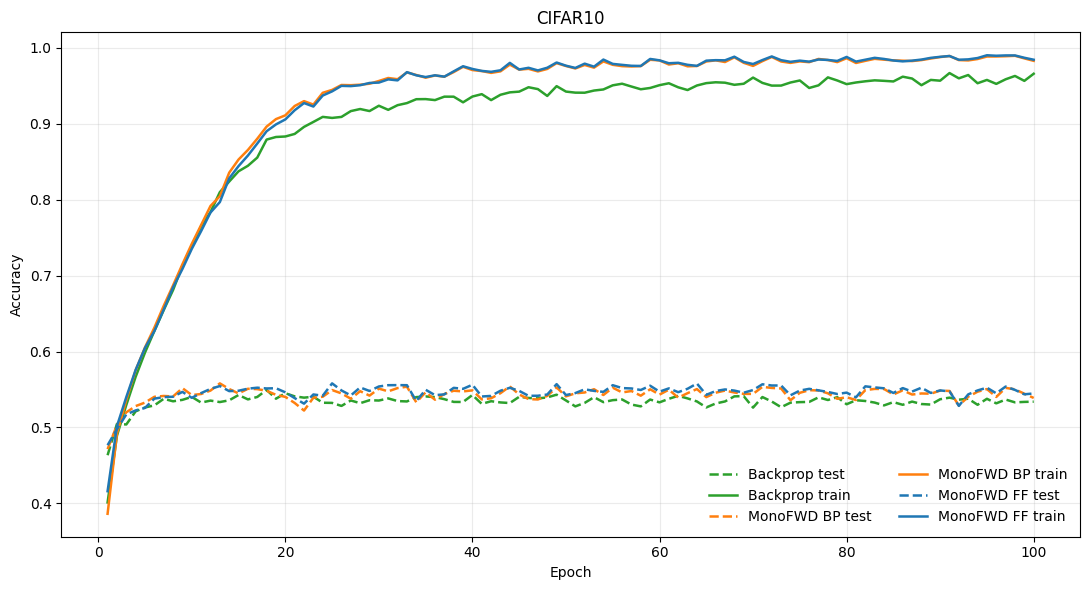

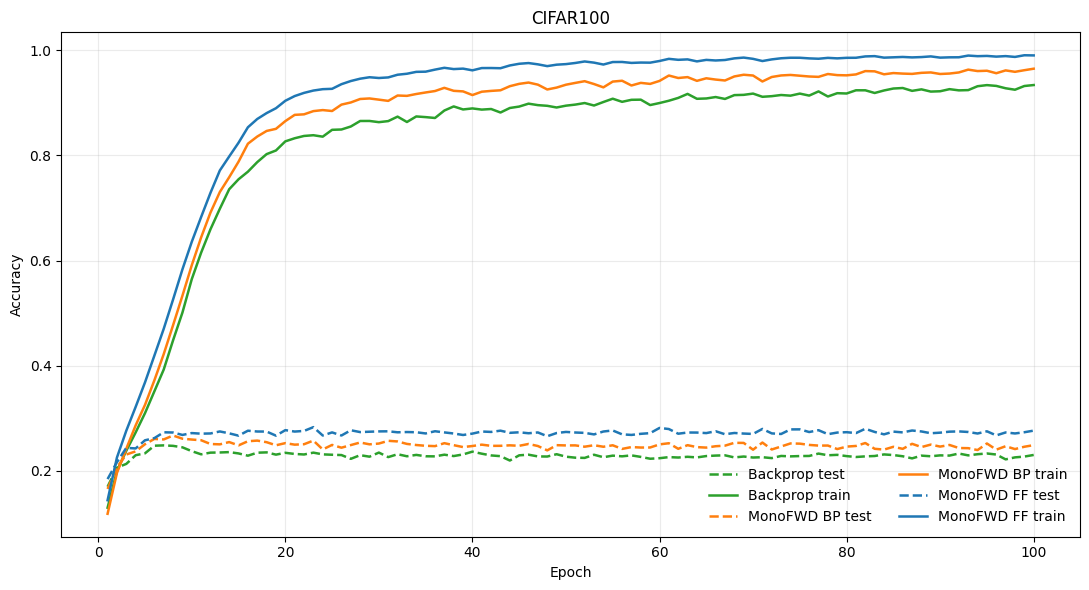

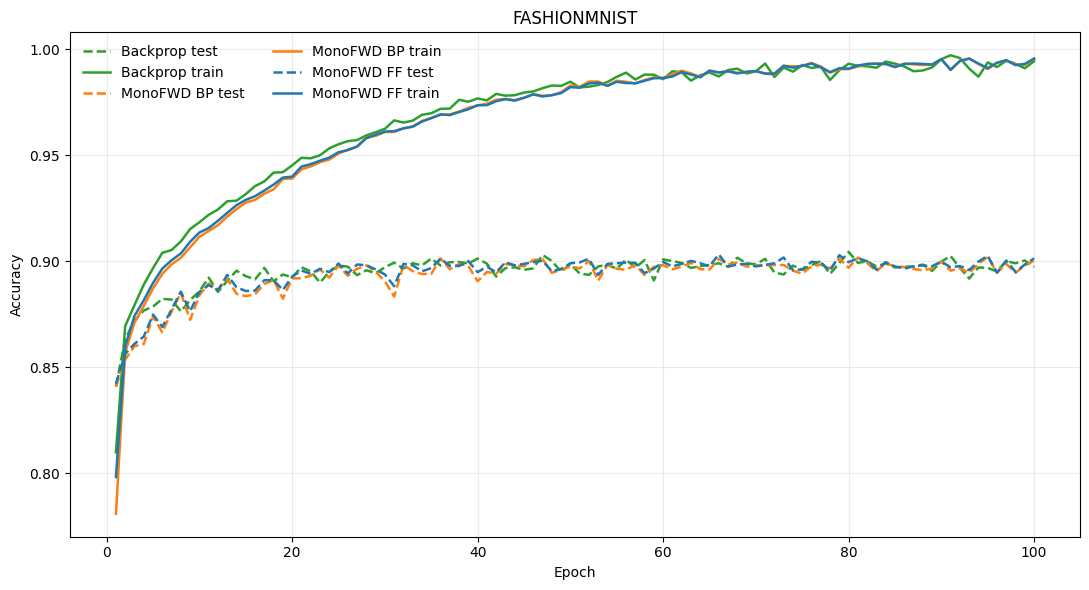

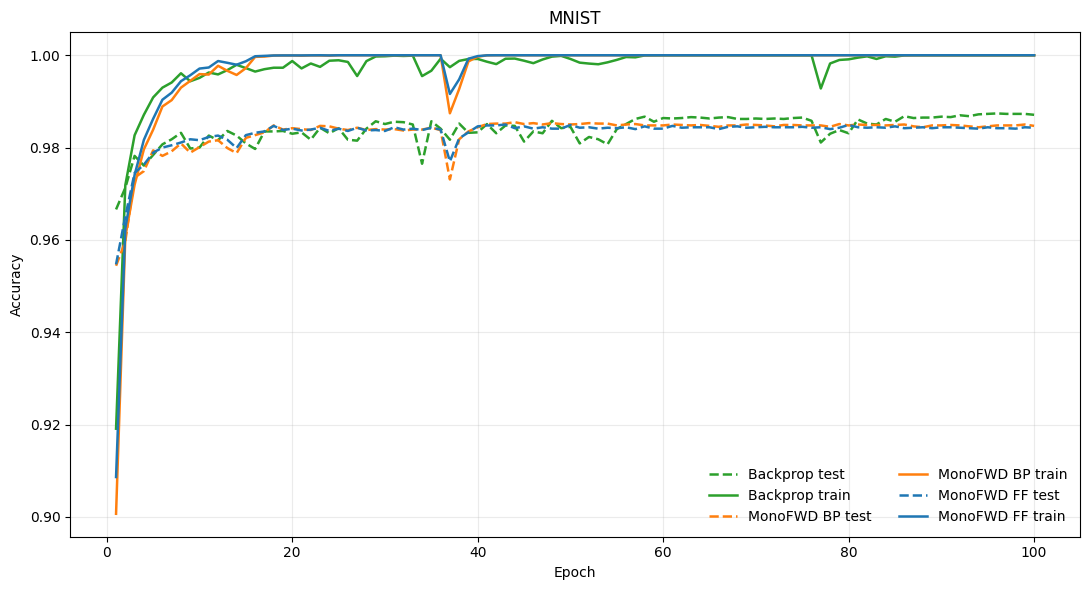

In [5]:
for dataset in sorted(accuracies["dataset"].unique()):
    fig, ax = plt.subplots(figsize=(11, 6))
    dataset_accuracies = accuracies[accuracies["dataset"] == dataset]

    for (method_label, split), group in dataset_accuracies.groupby(["method_label", "split"]):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(dataset.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()